# NVDA — The Discovery Loop: Can News Patterns Pass a Statistical Gate?

> **Part 5 of 6.** Builds on [`04_systematic_backtest_eval.ipynb`](04_systematic_backtest_eval.ipynb).
> Next: [`06_protected_2026_eval.ipynb`](06_protected_2026_eval.ipynb) (the one-time 2026 evaluation of a loosened gate).

Notebook 4 ended on what a stateless agent cannot do: learn that a kind of news has
historically preceded shocks. This notebook runs the loop that would teach it:

1. **Propose** a candidate pattern, a yes/no rule such as "NVDA reported earnings after
   today's close" or "a hyperscaler cut its AI capex".
2. **Label** every study window: was the pattern present by that window's cutoff?
3. **Score** it against matched calm days, on 2020–January 2025 *and* on 2025, the year
   after the models' training cutoff.
4. **Graduate** it into the strategy file only if it clears the gate on both.

**The result:** fifteen candidates in seven experiments, two pre-registered rounds,
\$16.23 spent, and **nothing graduated**. This notebook shows why, and why that is the
gate working, not failing.

> Reads committed experiment trails only. Run from `implementations/`; no LLM calls.

In [1]:
import warnings
from datetime import datetime


warnings.filterwarnings("ignore")

import pandas as pd
import yaml
from ai_stocks_forecasting import signals
from ai_stocks_forecasting.data import NVDA_SERIES_ID, build_nvda_service
from ai_stocks_forecasting.discovery import EXPERIMENTS_DIR, build_study_set, holdout_pass_rate, share_before_shocks
from ai_stocks_forecasting.news_labels import load_labels
from ai_stocks_forecasting.story import discovery_results, two_halves_chart


pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 70)
study = build_study_set(build_nvda_service().get_series(NVDA_SERIES_ID, as_of=datetime.now()))

---

## 1. The study windows

Each **shock window** ends the session before a ±5% move; each **control** is a calm
session matched on era and on trailing volatility, so a pattern that merely tracks
"volatile times" cannot pass for a shock predictor.

In [2]:
pd.DataFrame(
    {
        "period": ["2020 – Jan 2025", "Feb – Dec 2025"],
        "role": ["training (discovery)", "holdout (after the model cutoff)"],
        "windows": [len(study.train), len(study.holdout)],
        "shocks": [sum(w.is_shock for w in study.train), sum(w.is_shock for w in study.holdout)],
        "controls per shock": [1, 3],
        "shock rate (all sessions)": [f"{study.base_rate('train'):.1%}", f"{study.base_rate('holdout'):.1%}"],
    }
)

,period,role,windows,shocks,controls per shock,shock rate (all sessions)
0,2020 – Jan 2025,training (discovery),238,119,1,12.1%
1,Feb – Dec 2025,holdout (after the model cutoff),52,13,3,7.0%


## 2. The gate

A pattern graduates only if **all six** hold. The engine computes every number itself; a
study agent can propose a rule but cannot hand in its own statistics.

In [3]:
pd.DataFrame(
    [
        ("training", "matches", f">= {signals.MIN_MATCHES} windows", "enough examples to measure"),
        ("training", "lift", f">= {signals.MIN_LIFT}", "shocks at least twice as likely when present"),
        ("training", "p-value", f"< {signals.MAX_P_VALUE}", "Fisher's exact test against matched controls"),
        ("training", "lift interval", "lower end > 1", "95% bootstrap interval excludes 'no effect'"),
        ("holdout", "lift", f">= {signals.MIN_HOLDOUT_LIFT}", "still useful after the cutoff"),
        ("holdout", "p-value", f"< {signals.MAX_HOLDOUT_P_VALUE}", "not luck after the cutoff"),
    ],
    columns=["split", "criterion", "threshold", "what it guards against"],
)

,split,criterion,threshold,what it guards against
0,training,matches,>= 5 windows,enough examples to measure
1,training,lift,>= 2.0,shocks at least twice as likely when present
2,training,p-value,< 0.05,Fisher's exact test against matched controls
3,training,lift interval,lower end > 1,95% bootstrap interval excludes 'no effect'
4,holdout,lift,>= 1.5,still useful after the cutoff
5,holdout,p-value,< 0.1,not luck after the cutoff


**Why a post-cutoff holdout at all?** Both models were trained on news up to about
January 2025. A pattern found in 2020–2024 may be something the model *remembers*,
not something it can *detect*. Only 2025 data tests the second.

---

## 3. How a news label is made

For a news question, each window gets a web search **fenced at that window's own
cutoff**: a 2022 window only sees news published by its date, a verifier on a second
model audits the result, and a rule drops any sentence dated later. A judge model then
answers yes or no from the verified briefing. Two labels from the pilot show the fence
working:

In [4]:
pilot = load_labels("pilot_export_controls")
pd.DataFrame(
    [
        {"as_of": day, "answer": v["answer"], "evidence": v["evidence"]}
        for day, v in pilot.items()
        if day != "2021-06-15"
    ]
)

,as_of,answer,evidence
0,2022-08-31,yes,NVIDIA announced that it had received notification from the U.S. g...
1,2023-10-16,no,there were no official announcements of new or tightened U.S. gove...


On **2022-08-31** it found NVIDIA's disclosure of new licence requirements for A100/H100
exports to China. On **2023-10-16** it answered *no*: the October 2023 rule was announced
the next day, and the fence kept it out.

**Cost control.** Each question is screened on the holdout first (about \$0.55–\$0.95); its
238 training windows are labelled only if it survives, because failing the holdout
already rules out graduation. Every call is metered and the stage stops before a \$30 cap.

In [5]:
ledger = yaml.safe_load((EXPERIMENTS_DIR / "budget.yaml").read_text())
print(
    f"Spent ${ledger['spent_usd']:.2f} of the ${ledger['cap_usd']:.0f} cap across {len(ledger['entries'])} labelling runs"
)

Spent $16.23 of the $30 cap across 20 labelling runs


---

## 4. Results: fifteen candidates, none graduated

In [6]:
results = discovery_results()
columns = [
    "experiment",
    "candidate",
    "direction",
    "train_lift",
    "train_p",
    "holdout_matches",
    "holdout_hits",
    "holdout_lift",
    "holdout_p",
    "why_not",
]
results[columns].round(3)

,experiment,candidate,direction,train_lift,train_p,holdout_matches,holdout_hits,holdout_lift,holdout_p,why_not
0,exp01_earnings,P-1,either,3.165,0.030,4,1,3.581,0.253,"real before the cutoff, not after"
1,exp01_earnings,P-2,up,2.508,0.072,4,0,0.000,1.000,no effect
2,exp01_earnings,P-3,either,1.151,0.210,60,8,1.909,0.030,"real after the cutoff, not before"
3,exp02_export_controls,q1,either,NaN,NaN,4,1,1.000,0.696,no effect
4,exp02_export_controls,q2,either,NaN,NaN,0,0,NaN,1.000,no effect
5,exp03_hyperscaler_capex,q1,up,NaN,NaN,4,0,0.000,1.000,no effect
6,exp03_hyperscaler_capex,q2,down,NaN,NaN,1,1,25.556,0.135,one event
7,exp04_competitor_launches,q1,down,NaN,NaN,3,0,0.000,1.000,no effect
8,exp04_competitor_launches,q2,down,NaN,NaN,5,0,0.000,1.000,no effect
9,exp05_nvda_corporate,q1,up,NaN,NaN,7,1,1.267,0.600,no effect


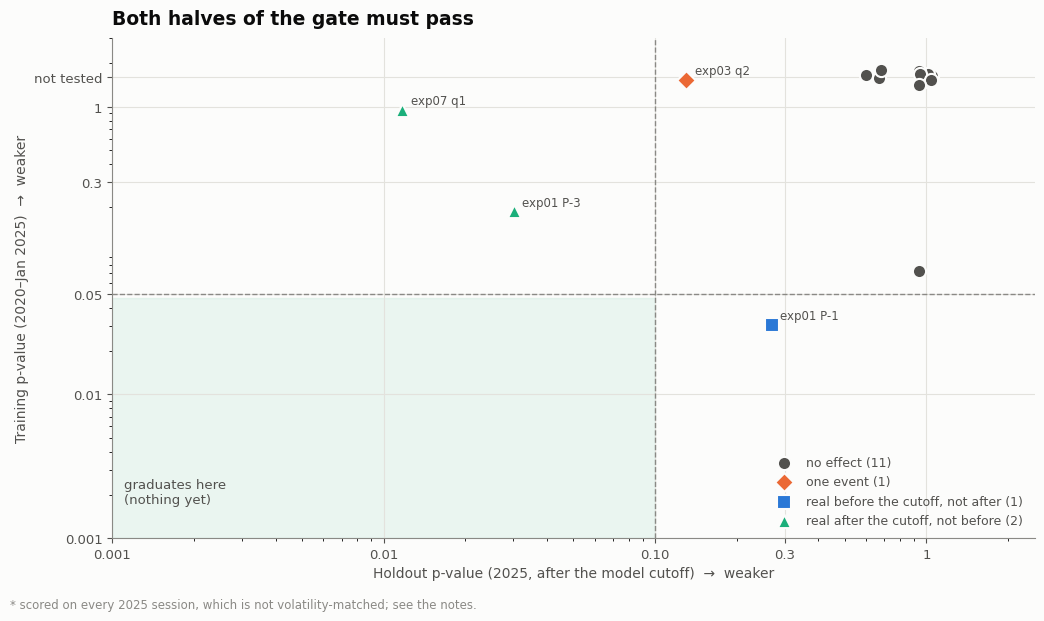

In [7]:
fig, ax = two_halves_chart(results)

**How to read it.** Each point is a candidate. Left is stronger evidence in 2025,
lower is stronger evidence in 2020–2024. A pattern graduates only in the shaded
bottom-left corner. Candidates screened out on the holdout never got a training test,
so they sit on the "not tested" strip at the top.

Four reasons, each a different lesson:

| Reason | Candidates | What it means |
|---|---|---|
| **No effect** | 11 (export controls, capex raised, rival chips, efficiency breakthroughs, product launches, Fed, CPI, …) | Reported before calm days at least as often as before shocks. No edge to find |
| **One event** | capex caution (down) | Its single 2025 match preceded a shock (p 0.135). One example cannot be significant: a lead, not a pattern |
| **Real before the cutoff, not after** | earnings | 9 of 11 earnings sessions preceded a shock in 2020–24; only 1 of 4 did in 2025. Exactly what the holdout exists to catch |
| **Real after the cutoff, not before** | peer results; high volatility\* | Peer results: 4 of 5 matches preceded shocks in 2025, but in 2020–24 lift was 0.77 over 49 matches. A 2025 coincidence |

\* High volatility passes only on the every-session holdout, which is not
volatility-matched. Against matched controls it has no edge (training lift 1.15), which is
the point of matching.

---

## 5. Is the gate too strict? Holdout power

The holdout has only **13 shocks**. A p-value cannot be small on a sample that size
unless a pattern matches several of them. Below: how often the holdout criteria pass
a pattern that appears before 3% of calm days, by design and true effect.

In [8]:
rows = []
for k in (1, 3, 5):
    rows.append(
        {
            "controls per shock": k,
            "no effect (false pass)": f"{holdout_pass_rate(0.03, 0.03, controls_per_shock=k):.1%}",
            "lift 3 (power)": f"{holdout_pass_rate(share_before_shocks(3, 0.03), 0.03, controls_per_shock=k):.1%}",
            "lift 5 (power)": f"{holdout_pass_rate(share_before_shocks(5, 0.03), 0.03, controls_per_shock=k):.1%}",
        }
    )
pd.DataFrame(rows).set_index("controls per shock")

,no effect (false pass),lift 3 (power),lift 5 (power)
controls per shock,,,
1,0.0%,3.0%,23.4%
3,2.1%,21.7%,59.7%
5,2.7%,25.3%,64.3%


- With **one control per shock** (the original design) a real lift-3 pattern passed 3% of
  the time: a pattern had to precede at least 4 of 13 shocks with no false alarm. The
  first screens failed on sample size, not evidence.
- **Three controls per shock** (adopted, training unchanged, no threshold changed) raise that
  to 22% while keeping the false-pass rate near 2%. Five add little more.
- The redesign came after the first screens, so both results are kept in the trails.
- **Multiple testing.** Fifteen candidates with no effect would produce 0.3–0.9 holdout
  passes by chance. One appeared (peer results) and the training half rejected it.

So the gate is not too strict in its thresholds. It is limited by how many post-cutoff
shocks one stock produces in one year.

---

## 6. Takeaways

- **Ordinary news categories did not predict NVDA's ±5% days** beyond what volatility already
  explains, on data the models could not have memorised.
- **The gate did its job twice**: it rejected a pattern that was strong before the cutoff
  (earnings) and one that was strong after it (peer results). Either alone would have
  looked convincing.
- **The master strategy file is empty**, so the adaptive forecaster has nothing to read yet,
  and a with/without comparison would compare identical forecasters.

**What would change the picture**

1. **More post-cutoff shocks.** Adding AMD, MSFT and GOOG (Phase 4) multiplies the
   events a pattern can be confirmed on; most real rare patterns cannot be confirmed on
   one stock and one year.
2. **Sharper questions.** "Capex caution" is the one lead. Refining it against the same
   holdout would be tuning on it; it needs fresh data to be tested fairly.
3. **The protected 2026 run**: [`06_protected_2026_eval.ipynb`](06_protected_2026_eval.ipynb) uses it once, to test what a loosened gate buys.